In [35]:

import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt
import seaborn as sns

os.chdir("/data/scottaa/cta_onco_fetal")

In [36]:
fetal_gonad_frac_df = pd.read_csv("datasets/fetal_gonad/results/tables/cta_analysis/fetal_gonad_Female_cta_fraction_expression.csv", index_col = 0)
embryos_mixed_frac_df = pd.read_csv("datasets/embryos_mixed/results/tables/cta_analysis/embryos_mixed_female_cta_fraction_expression.csv", index_col = 0)

all_cell_types = list(set(list(fetal_gonad_frac_df.index) + list(embryos_mixed_frac_df.index)))

cell_type_order = ['PGC', 'RA–responsive germ cells','Meiotic germ cells','Oocytes','Proliferating', 'Early somatic','Stromal','Endothelial','Epithelial','Immune', 'Ribosomal', 'Ambiguous', 'Unknown', 'Mixed' ]

In [49]:
all_genes = list(set(list(fetal_gonad_frac_df.columns) + list(embryos_mixed_frac_df.columns)))

gene_order = [

    # Early germ cell / pluripotency
    "PRDM14", "DPPA2", "NR6A1",

    # PGC / early germline
    "PRAME", "FAM133A",

    # Meiosis initiation / recombination
    "SPO11", "SYCP1", "HORMAD1", "HORMAD2",

    # Meiotic / germline machinery
    "TDRD1", "TDRD6", "MAEL", "TEX15", "RBM46", "MORC1",

    # Late germline / spermatogenic
    "TEX101", "TMPRSS12", "DMRT1",

    # Cancer-testis antigens (classic CTGs)
    "MAGEA4", "MAGEB2", "MAGEC2",
    "PAGE1", "PAGE2", "PAGE2B", "PAGE4", "PAGE5",
    "CTAG2", "CT47B1", "CTCFL",

    # Other CTGs / miscellaneous
    "CABYR", "SPANXN2", "LY6K", "TPTE", "PBK", "PLAC1",
    "IL13RA2", "LUZP4", "FMR1NB"
]

In [59]:
common = set(fetal_gonad_frac_df.columns) & set(embryos_mixed_frac_df.columns)

common
only_1 = set(fetal_gonad_frac_df.columns) - set(embryos_mixed_frac_df.columns)

print(list(only_1))

['CABYR', 'TDRD1', 'TMPRSS12', 'IL13RA2', 'TEX15', 'LUZP4', 'RBM46', 'PAGE2', 'BRDT', 'MAGEB2', 'PAGE2B', 'NR6A1', 'DPPA2', 'DMRT1', 'FMR1NB', 'SPANXN2', 'PLAC1', 'PBK', 'TPTE', 'LY6K', 'PRAME', 'PAGE4', 'CT47B1', 'MAEL', 'HORMAD1', 'FAM133A', 'TEX101']


In [60]:
common

{'CTAG2', 'CTCFL', 'MAGEA4', 'PAGE1', 'PAGE5', 'SPO11', 'SYCP1'}

In [ ]:
['LY6K', 'RBM46','PRAME','MAEL','TDRD1','PAGE2B','CABYR','HORMAD1','TEX15',]

In [68]:
adata_fetal = sc.read_h5ad("datasets/fetal_gonad/working_adata/fetal_gonad_Female_annotated.h5ad")
adata_embryo = sc.read_h5ad("datasets/embryos_mixed/working_adata/embryos_mixed_female_processed_annotated.h5ad")

/data/scottaa/conda/envs/rnaseq-pipe/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [86]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "axes.titlesize": 16
})

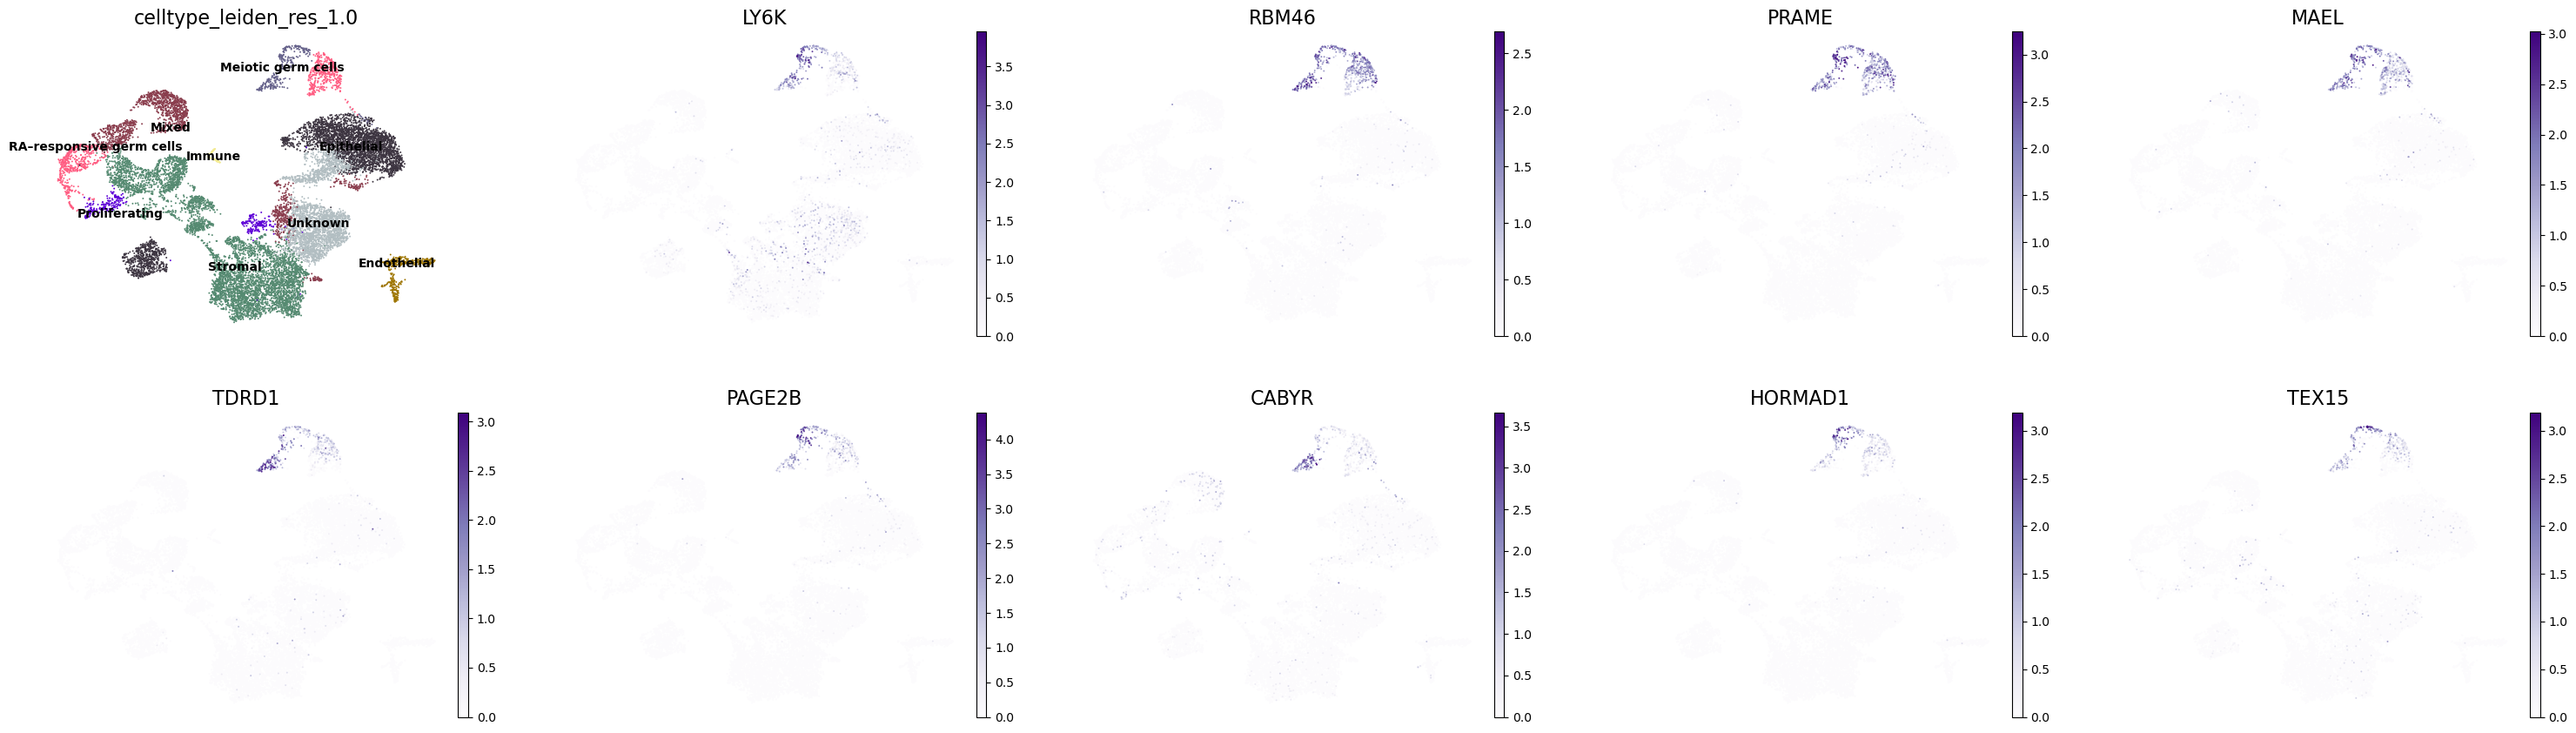

In [90]:
sc.pl.umap(adata_fetal,color= ['celltype_leiden_res_1.0', 'LY6K', 'RBM46','PRAME','MAEL','TDRD1','PAGE2B','CABYR','HORMAD1','TEX15',] , cmap = "Purples", legend_loc = "on data", frameon = False, ncols = 5)
#sc.pl.umap(adata_embryo,color=['celltype_leiden_res_1.0',"CTCFL", "CTAG2","PAGE5","SPO11", "SYCP1"], cmap = "Purples", legend_loc = "on data",frameon = False, ncols = 3)

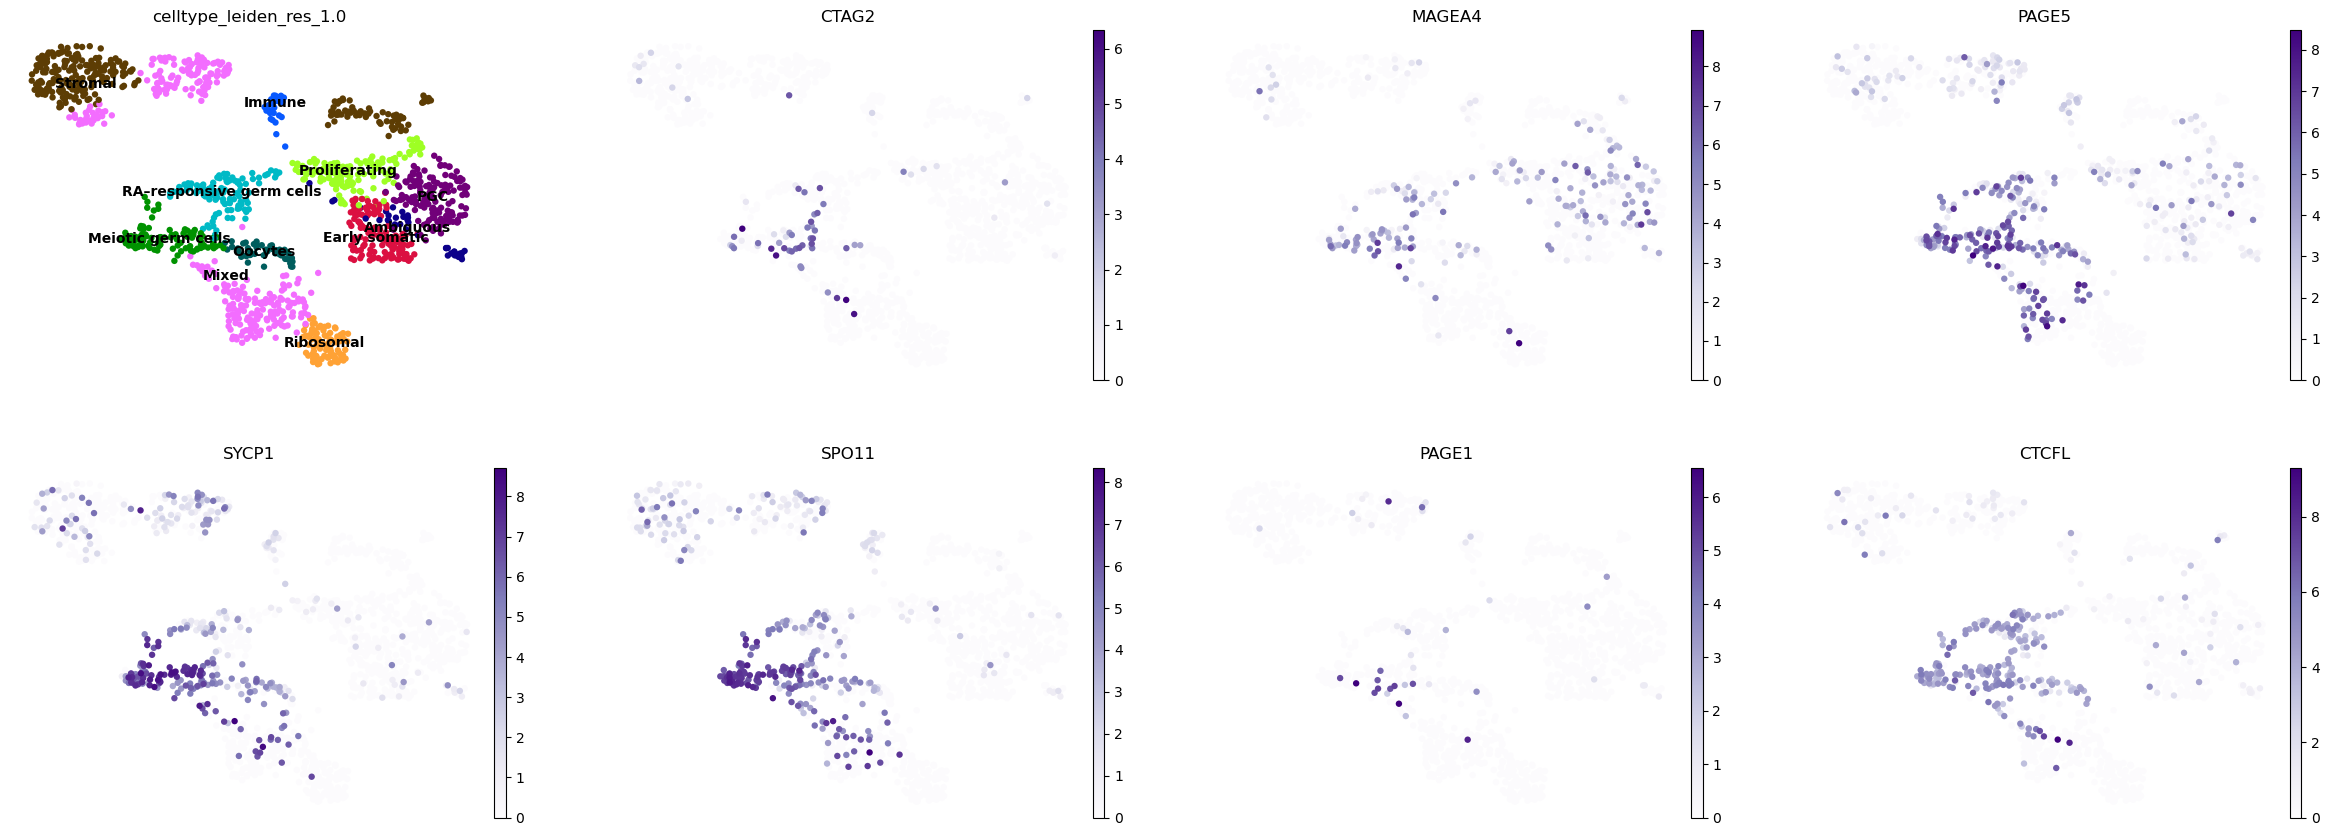

In [75]:
sc.pl.umap(adata_embryo,color=['celltype_leiden_res_1.0'] + list(common), cmap = "Purples", legend_loc = "on data",frameon = False)

In [50]:
df_fetal = fetal_gonad_frac_df.reindex(cell_type_order).fillna(0)
gene_order = [g for g in gene_order if g in df_fetal.columns]
df_fetal = df_fetal[gene_order]
df_embryo = embryos_mixed_frac_df.reindex(cell_type_order).fillna(0)
gene_order = [g for g in gene_order if g in df_embryo.columns]
df_embryo = df_embryo[gene_order]

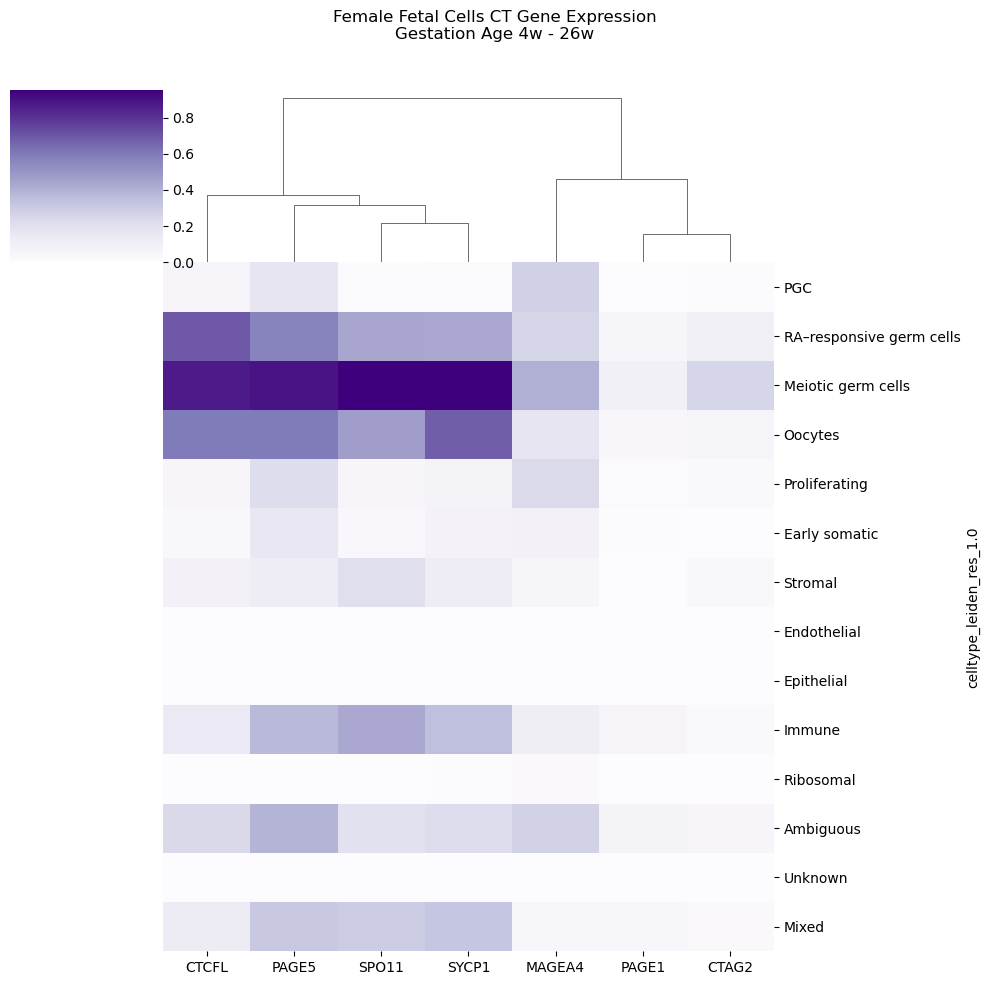

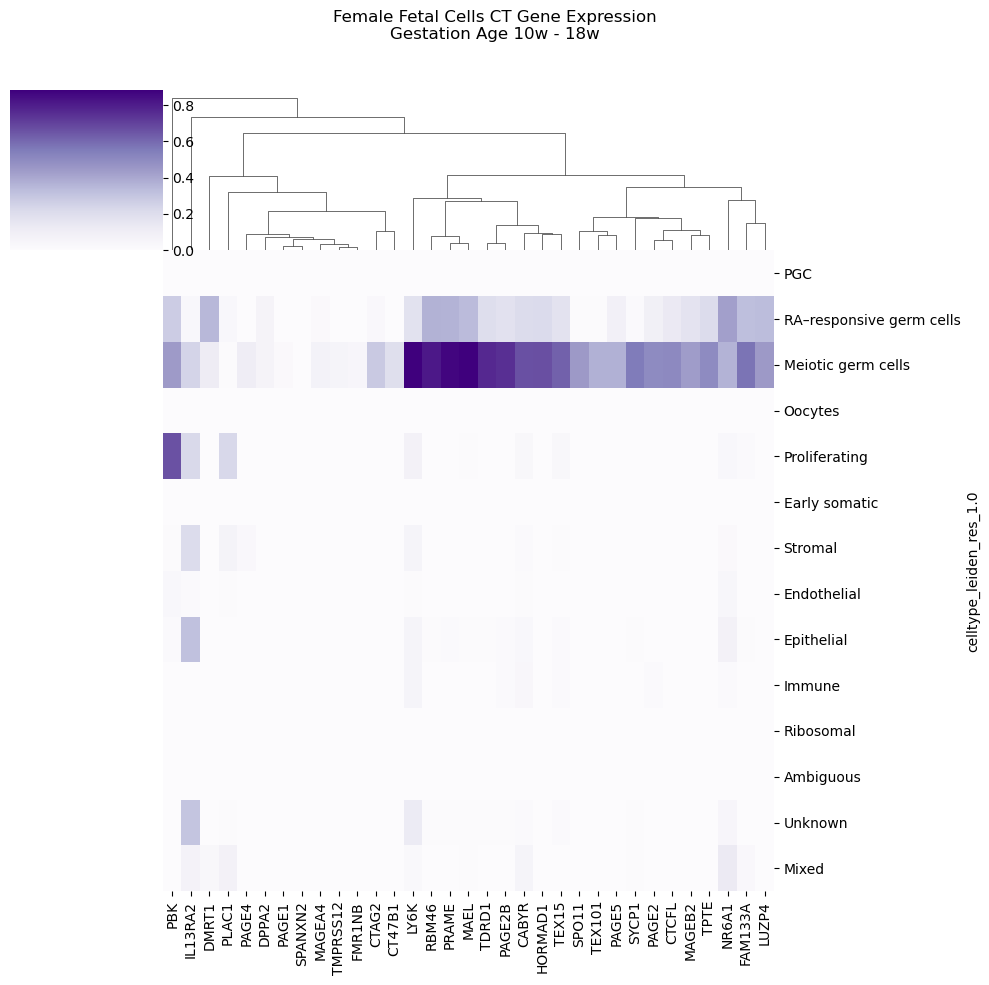

In [53]:
g = sns.clustermap(
    df_embryo,
    row_cluster=False,
    col_cluster=True,
    cmap="Purples"
)

g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 4w - 26w")
g.fig.subplots_adjust(top=0.9)


g = sns.clustermap(
    df_fetal,
    row_cluster=False,
    col_cluster=True,
    cmap="Purples"
)

g.fig.suptitle("Female Fetal Cells CT Gene Expression\nGestation Age 10w - 18w")
g.fig.subplots_adjust(top=0.9)

In [ ]:

sns.clustermap(df_embryo, cmap="Purples")

In [ ]:
import seaborn as sns
import pandas as pd

sns.clustermap(df_fetal, cmap="Purples")

sns.clustermap(df_embryo, cmap="Purples")

In [ ]:
sample_meta.index.unique()